# Esame Laboratorio di Programmazione II

Scrivete chiaramente sul notebook il vostro nome e matricola e salvate il file con il nome della vostra matricola.

Per ogni funzione o metodo che richiede un campionamento rispetto ad una distribuzione, settate il seed a 0: `np.random.seed(0)`.

Stampate il risultato delle domande e consegnate il compito eseguito: ogni cella deve avere il corrispondente output. Ad esempio, NON scrivete solo:

```python
lista = np.array([1, 2, 3])
```

ma:

```python
lista = np.array([1, 2, 3])
print('lista =', lista)
```

NB: se l'output è una matrice molto grande, non dovete stamparla integralmente.

Sarà valutata anche la presentazione: ad esempio, un plot senza titolo o senza etichette sugli assi sarà considerato incompleto.


In [20]:
# Qui potete mettere gli import delle librerie 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, root_mean_squared_log_error
from scipy.optimize import curve_fit
import seaborn  as sns


## Esercizio 1

Un gruppo di supereroi ha ottenuto i seguenti punteggi di energia dopo una missione:

`72, 85, 61, 90, 77, 88, 54, 69, 95, 81, 73, 66`

1. Crea un array NumPy `energia` con questi valori e calcola la **media**.
2. Tutti i valori **strettamente minori di 70** devono essere aumentati di 8 punti. Aggiorna l'array in-place e stampa il nuovo array.
3. Calcola quanti valori, dopo la correzione, sono **compresi tra 75 e 90 inclusi**.


In [3]:
#1
energia = np.array([72, 85, 61, 90, 77, 88, 54, 69, 95, 81, 73, 66])
media = np.mean(energia)
print(f"L'array energia è {energia}, e la media è {media}")
#2
condizione = energia < 70
energia[condizione] = energia[condizione]+8
print("Array aggiornato: \n", energia)
#3
vero_falso = (energia >=75) & (energia <= 90)
somma = np.sum(vero_falso)
print("Valori compresi tra 75 e 90: ", somma)

L'array energia è [72 85 61 90 77 88 54 69 95 81 73 66], e la media è 75.91666666666667
Array aggiornato: 
 [72 85 69 90 77 88 62 77 95 81 73 74]
Valori compresi tra 75 e 90:  6


## Esercizio 2

Un supereroe affronta una missione. L'esito della missione può essere:

- `successo`, con probabilità 0.65;
- `successo_parziale`, con probabilità 0.25;
- `fallimento`, con probabilità 0.10.

1. Scrivi una funzione `simula_missioni(N)` che simula `N` missioni e restituisce un array NumPy con gli esiti ottenuti.
2. Per valori di `N = 50, 100, 150, ..., 500`, esegui una simulazione e calcola la frequenza relativa di `successo` e di `fallimento`.
3. Rappresenta graficamente le frequenze relative di `successo` e `fallimento` in funzione di `N` e confrontale con i valori teorici.


Esempio di prova della funzione : 
 ['successo' 'successo_parziale' 'successo' 'successo' 'successo'
 'successo' 'successo' 'successo_parziale' 'fallimento' 'successo'
 'successo_parziale' 'successo' 'successo' 'fallimento' 'successo'
 'successo' 'successo' 'successo_parziale' 'successo_parziale'
 'successo_parziale']
Frequenza relativa successi: [np.float64(0.7), np.float64(0.67), np.float64(0.64), np.float64(0.66), np.float64(0.664), np.float64(0.6533333333333333), np.float64(0.66), np.float64(0.6675), np.float64(0.66), np.float64(0.658)], frequenza relativa fallimento: [np.float64(0.08), np.float64(0.09), np.float64(0.08666666666666667), np.float64(0.085), np.float64(0.092), np.float64(0.10333333333333333), np.float64(0.1), np.float64(0.1025), np.float64(0.1111111111111111), np.float64(0.112)]


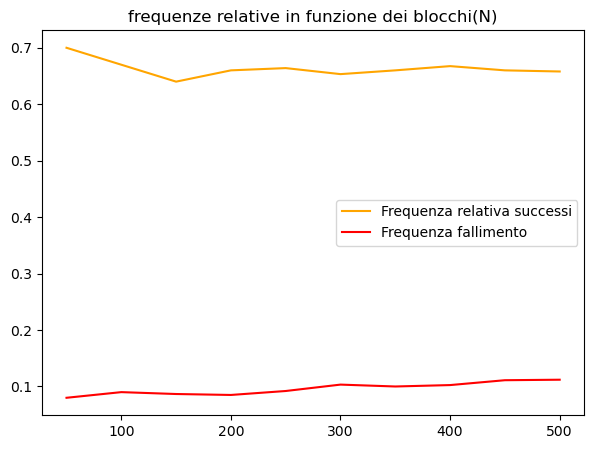

In [8]:
np.random.seed(0)
#1
def simula_missioni(N):
    risultato = np.random.choice(["successo", "successo_parziale", "fallimento"], size=N, p=(0.65,0.25,0.10))
    return risultato
#es di prova: 
prova = simula_missioni(20)
print("Esempio di prova della funzione : \n", prova)
#2
blocchi = np.arange(50, 501, 50)
totale = simula_missioni(500)
freq_succ = []
freq_fall = []
for n in blocchi:
    parziale = totale[:n]
    freq_parz_succ = np.sum(parziale == "successo")/n
    freq_parz_fall = np.sum(parziale == "fallimento")/n
    freq_succ.append(freq_parz_succ)
    freq_fall.append(freq_parz_fall)
print(f"Frequenza relativa successi: {freq_succ}, frequenza relativa fallimento: {freq_fall}")
#3
plt.figure(figsize=(7,5))
plt.plot(blocchi, freq_succ, color= "orange", label="Frequenza relativa successi")
plt.plot(blocchi, freq_fall, color="red", label="Frequenza fallimento")
plt.title("frequenze relative in funzione dei blocchi(N)")
plt.legend()
plt.show()


## Esercizio 3

1. Genera una matrice NumPy di dimensioni 6 × 8, con valori estratti da una distribuzione normale con media = 50 e deviazione standard = 10.

2. Per ogni riga, individua il valore massimo e il valore minimo.

3. Costruisci un array contenente, per ogni riga, la differenza tra il valore massimo e il valore minimo.

4. Calcola quante righe hanno una differenza maggiore di 20.

In [5]:
#1
np.random.seed(0)
matrice = np.random.normal(loc=50, scale=10, size=(6,8))
print("matrice : \n", matrice)
#2
max = np.max(matrice, axis=1)
min = np.min(matrice, axis = 1)
#3
differenza = max- min
print(differenza)
#4
vero_falso = differenza > 20
print(vero_falso)
somma = np.sum(vero_falso)
print(somma)

matrice : 
 [[67.64052346 54.00157208 59.78737984 72.40893199 68.6755799  40.2272212
  59.50088418 48.48642792]
 [48.96781148 54.10598502 51.44043571 64.54273507 57.61037725 51.21675016
  54.43863233 53.33674327]
 [64.94079073 47.94841736 53.13067702 41.45904261 24.47010184 56.53618595
  58.64436199 42.5783498 ]
 [72.69754624 35.45634325 50.45758517 48.1281615  65.32779214 64.6935877
  51.54947426 53.7816252 ]
 [41.12214252 30.19203532 46.52087851 51.56348969 62.30290681 62.02379849
  46.12673183 46.97697249]
 [39.51447035 35.79982063 32.93729809 69.50775395 44.90347818 45.61925698
  37.4720464  57.77490356]]
[32.18171079 15.57492359 40.47068889 37.24120299 32.11087149 36.57045586]
[ True False  True  True  True  True]
5


## Esercizio 4

Utilizza il dataset `heroes.csv`, che contiene le seguenti colonne:

`hero_id`, `hero`, `universe`, `strength`, `speed`, `intelligence`, `missions`, `success_rate`, `power_type`.

1. Verifica la presenza di **valori mancanti per colonna** ed elimina le righe che ne contengono.

2. Crea una nuova colonna `mission_score` definita come:

   $$
   \texttt{mission\_score}
   =
   \texttt{missions}
   \times
   \texttt{success\_rate}
   $$

3. Calcola il valore medio di `mission_score` per ciascun universo (`Marvel` e `DC`) e determina quale universo ha il valore medio più elevato.

4. Crea un **grafico a barre** che mostri il valore medio di `mission_score` per ciascun universo.

5. Crea uno **scatter plot** con:
   - asse x = `strength`
   - asse y = `success_rate`
   - colore dei punti = `mission_score`

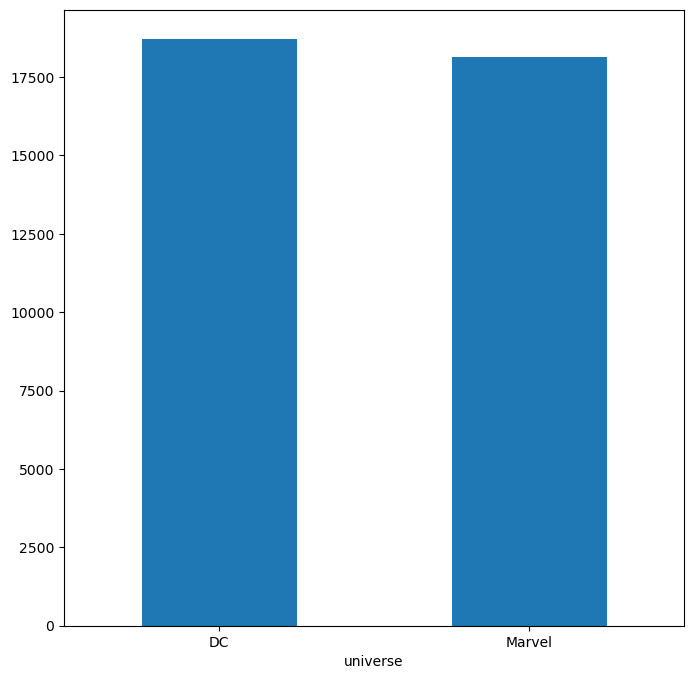

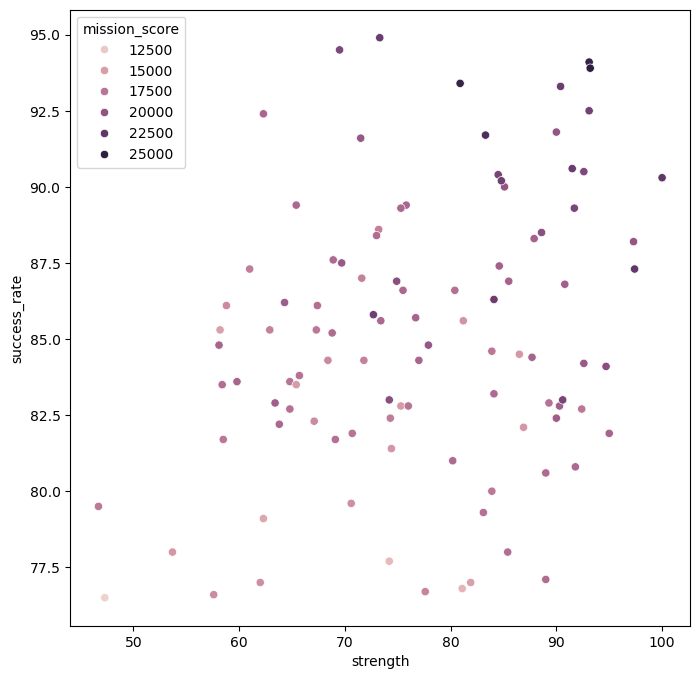

In [21]:
#1
df = pd.read_csv("heroes.csv")
val_manc = df.isnull().sum()
df = df.dropna()
#2
df["mission_score"]=df["missions"]*df["success_rate"]
#3
medio_m_s = df.groupby("universe")["mission_score"].mean()
medio_m_s
max = (np.max(medio_m_s))
#4
plt.figure(figsize=(8,8))
medio_m_s.plot(kind="bar")
plt.xticks(rotation=0)
#5
plt.figure(figsize=(8,8))
sns.scatterplot(data=df, x="strength", y="success_rate", hue="mission_score")
plt.show()

## Esercizio 5

**Prima di svolgere questo esercizio, ricaricare il dataset originale `heroes.csv`.**

Si utilizzi di nuovo il dataset `heroes.csv`.

Svolgere le seguenti richieste:

1. Determinare il numero di righe e di colonne del dataset ed eliminare la colonna `hero_id`.
2. Individuare il `power_type` più frequente nel dataset.
3. Calcolare la media di `success_rate` per ciascun `power_type` e ordinare i risultati dal valore medio più alto al più basso.
4. Rappresentare la distribuzione di `success_rate` per ciascun `power_type` mediante un boxplot.
5. Calcolare la percentuale di eroi con `success_rate >= 90` e con `success_rate < 90` **usando una list comprehension**, e rappresentare tali percentuali con un grafico a torta (pie chart).


<Axes: xlabel='power_type', ylabel='success_rate'>

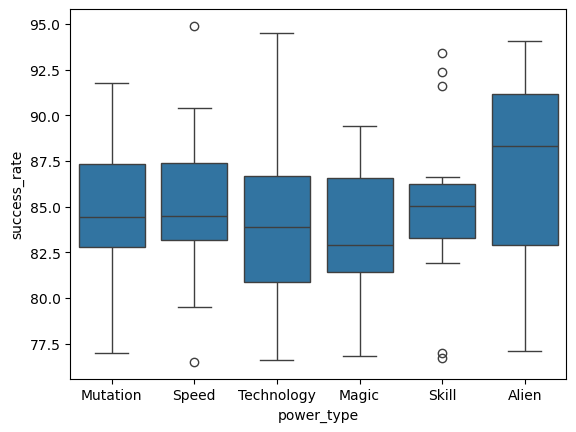

In [ ]:
df = pd.read_csv("heroes.csv")
dimensioni = df.shape

p_t_freq = df["power_type"].mode()[0]

raggrup = df.groupby("power_type")["success_rate"].mean()
raggrup = raggrup.sort_values(ascending=False)

sns.boxplot(data=df, x="power_type", y="success_rate")



## Esercizio 6

Hai a disposizione il dataset di coppie `(x, y)` qui sotto riportato.

1. Stima i parametri della retta del tipo

   $$
   y = a \cdot x + b
   $$

   usando `scipy.optimize.curve_fit`.
2. Plotta i punti originali e la retta ottenuta.
3. Calcola **MAE** (Mean Absolute Error) e **RMSE** (Root Mean Squared Error) tra i valori reali `y` e quelli stimati dal modello, dove:

   $$
   \text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
   $$  

   $$
   \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
   $$


In [27]:
x = np.array([
    0.0, 0.5, 1.0, 1.5, 2.0, 2.5,
    3.0, 3.5, 4.0, 4.5, 5.0, 5.5,
    6.0, 6.5, 7.0, 7.5, 8.0, 8.5,
    9.0, 9.5, 10.0
])

y = np.array([
    2.1, 3.2, 4.7, 6.0, 7.5, 8.8,
    10.2, 12.0, 13.1, 14.9, 16.3, 17.8,
    19.0, 20.7, 22.1, 23.6, 25.2, 26.4,
    28.0, 29.3, 31.1
])
